# Sobreprecio en gasolineras de la Zona Metropolitana de Monterrey

**Análisis del mercado de Magna (gasolina regular) en la ZM Monterrey, enero–febrero 2026**

---

## Pregunta de negocio

> ¿Qué gasolineras de la Zona Metropolitana de Monterrey cobran Magna sobre el precio coordinado del mercado, con qué persistencia, y cuánto le cuesta al consumidor desinformado al año?

## Cliente hipotético

Una aplicación de comparación de precios de combustible (tipo Gasolina MX, Waze) o un medio de periodismo de datos que necesite identificar y publicar las estaciones que cobran arriba del precio de mercado en su zona.

## Datos

- **Fuente primaria**: Comisión Nacional de Energía (CNE) – Datos abiertos de México.
  - Precios diarios de combustibles por permisionario (enero y febrero 2026).
  - Catálogo de permisos vigentes de expendio al público.
  - Padrón geográfico de estaciones de servicio (XML, formato CRE histórico).
- **Ventana de análisis**: 58 días contiguos (1 enero – 28 febrero 2026, con un día faltante en el archivo público).
- **Población final de análisis**: 572 estaciones de la ZM Monterrey con cobertura ≥70% del periodo.

## Metodología en una frase

Se identifica el precio de referencia del mercado (modal nacional), se calcula el sobreprecio absoluto de cada estación contra ese benchmark, y se aplica un criterio de persistencia (≥30% de días con sobreprecio ≥$0.20/L) para distinguir comportamiento sistemático de fluctuaciones aisladas.

## Hallazgos principales

1. El mercado mexicano de Magna está fuertemente clusterizado: **72.7% de las observaciones** en la ZM Monterrey se reportan al precio coordinado de **$23.99/L**.
2. Solo **31 estaciones de 572** rompen el precio coordinado en algún día. Solo **12** lo hacen de manera sistemática (≥30% del periodo).
3. **11 de las 12 son operaciones de la marca Petromax**, pero representan apenas **9.7% de las 113 Petromax** con cobertura suficiente. El patrón es de **subgrupo específico, no de marca completa**.
4. Las 11 Petromax con sobreprecio sistemático están concentradas en el **corredor oriente de la ZM Monterrey** (Apodaca–Guadalupe–Juárez–Cadereyta), no en zonas tradicionalmente premium como San Pedro Garza García.
5. El sobreprecio anual real para un consumidor que llena 50 L semanales en una de estas 11 estaciones está entre **$390 y $1,040 al año**, dependiendo del nivel de sobreprecio y frecuencia de visita.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Rutas
PROJECT_ROOT = Path.home() / "proyectos" / "gasolineras-mty"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

# Cargar datasets procesados (generados en 01_eda.ipynb)
estaciones = pd.read_parquet(DATA_PROCESSED / "estaciones_zm_monterrey.parquet")
magna = pd.read_parquet(DATA_PROCESSED / "magna_zm_diario.parquet")
candidatas = pd.read_parquet(DATA_PROCESSED / "estaciones_caras_candidatas.parquet")

# Constantes del análisis
PRECIO_REFERENCIA = 23.99
UMBRAL_SOBREPRECIO = 0.20
UMBRAL_PRECIO_CARO = PRECIO_REFERENCIA + UMBRAL_SOBREPRECIO  # 24.19
PERSISTENCIA_MIN = 0.30  # 30% de los días observados

print(f"Estaciones en ZM Monterrey: {len(estaciones)}")
print(f"Observaciones de Magna: {len(magna):,}")
print(f"Días observados: {magna['fecha'].nunique()}")
print(f"Estaciones identificadas como sistemáticamente caras: {len(candidatas)}")
print(f"\nUmbrales del análisis:")
print(f"  Precio de referencia: ${PRECIO_REFERENCIA}/L")
print(f"  Umbral de sobreprecio: ${UMBRAL_SOBREPRECIO}/L")
print(f"  Persistencia mínima: {PERSISTENCIA_MIN*100:.0f}% de días")

Estaciones en ZM Monterrey: 620
Observaciones de Magna: 33,391
Días observados: 58
Estaciones identificadas como sistemáticamente caras: 12

Umbrales del análisis:
  Precio de referencia: $23.99/L
  Umbral de sobreprecio: $0.2/L
  Persistencia mínima: 30% de días


## Hallazgo 1 — El mercado está fuertemente clusterizado en un precio único

A nivel nacional, **41% de las observaciones de Magna** se reportan a exactamente **$23.99/L**. En la ZM Monterrey este porcentaje sube a **72.7%**: prácticamente tres de cada cuatro registros estación-día reportan ese precio idéntico.

Este patrón es inconsistente con un mercado de fijación de precios independiente y sugiere precios de referencia compartidos entre operadores. Para efectos del análisis, **el precio de referencia ($23.99/L) sustituye a la mediana de vecindad de 3 km que originalmente se contemplaba como benchmark**: el clustering hace ambos enfoques numéricamente equivalentes en la mayoría de zonas.

Esta concentración tiene una implicación práctica importante: cualquier estación que se separe de $23.99 hacia arriba lo hace **deliberadamente**, no por azar. La pregunta de negocio puede entonces formularse como: *¿quién y dónde se aparta del precio coordinado?*

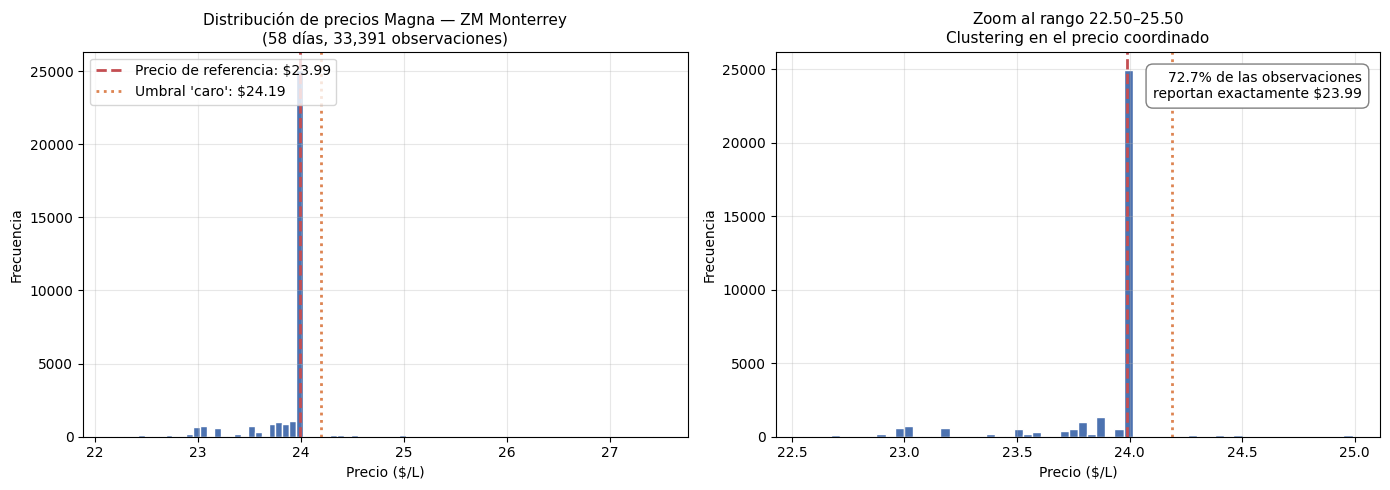

In [2]:
# Distribución de precios en la ZM Monterrey
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: vista completa
axes[0].hist(magna["precio"], bins=80, color="#4C72B0", edgecolor="white")
axes[0].axvline(PRECIO_REFERENCIA, color="#C44E52", linestyle="--", linewidth=2,
                label=f"Precio de referencia: ${PRECIO_REFERENCIA}")
axes[0].axvline(UMBRAL_PRECIO_CARO, color="#DD8452", linestyle=":", linewidth=2,
                    label=f"Umbral 'caro': ${UMBRAL_PRECIO_CARO:.2f}")
axes[0].set_title("Distribución de precios Magna — ZM Monterrey\n(58 días, 33,391 observaciones)", fontsize=11)
axes[0].set_xlabel("Precio ($/L)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel derecho: zoom al rango central + nota del 72.7%
zoom_data = magna[magna["precio"].between(22.5, 25.5)]
axes[1].hist(zoom_data["precio"], bins=60, color="#4C72B0", edgecolor="white")
axes[1].axvline(PRECIO_REFERENCIA, color="#C44E52", linestyle="--", linewidth=2)
axes[1].axvline(UMBRAL_PRECIO_CARO, color="#DD8452", linestyle=":", linewidth=2)

pct_2399 = (magna["precio"] == PRECIO_REFERENCIA).sum() / len(magna) * 100
axes[1].text(0.97, 0.95,
             f"{pct_2399:.1f}% de las observaciones\nreportan exactamente $23.99",
             transform=axes[1].transAxes,
             ha="right", va="top",
             fontsize=10,
             bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.5"))

axes[1].set_title("Zoom al rango $22.50–$25.50\nClustering en el precio coordinado", fontsize=11)
axes[1].set_xlabel("Precio ($/L)")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "processed" / "fig01_clustering.png", bbox_inches="tight")
plt.show()

## Hallazgo 2 — Solo 12 estaciones rompen el precio coordinado de manera sistemática

Aplicando el criterio de **sobreprecio ≥$0.20/L sobre el precio de referencia, en al menos 30% de los días observados**, se identifican **12 estaciones** sobre las 572 con cobertura suficiente. Esto representa apenas **2.1% del mercado de la ZM Monterrey**.

El criterio combina dos condiciones:

- **Magnitud**: $0.20/L absoluto sobre $23.99 ($24.19 o más). Justificación monetaria: $0.20 × 50 L semanales × 52 semanas = $520 anuales — un consumidor mexicano percibe esa cantidad.
- **Persistencia**: ≥30% de los días observados con sobreprecio. Justificación estadística: el "codo natural" de la distribución separa estaciones con comportamiento sistemático de casos aislados (un día anómalo en una estación con 58 observaciones).

La tabla siguiente muestra las 12 estaciones identificadas, ordenadas por persistencia del sobreprecio.

In [3]:
from IPython.display import display, HTML

# Tabla formateada de las 12 estaciones que rompen el precio
tabla_caras = candidatas.copy()
tabla_caras = tabla_caras.sort_values("pct_dias_caros", ascending=False).reset_index(drop=True)

# Calcular costo anual al consumidor
# Asunción: consumo de 50 L/semana, 52 semanas/año
tabla_caras["sobreprecio_dias_caros"] = (
    tabla_caras["precio_promedio_dias_caros"] - PRECIO_REFERENCIA
).round(2)

tabla_caras["costo_anual_aleatorio"] = (
    tabla_caras["sobreprecio_dias_caros"]
    * (tabla_caras["pct_dias_caros"] / 100)
    * 50  # litros/semana
    * 52  # semanas/año
).round(0).astype(int)

tabla_caras["costo_anual_siempre"] = (
    tabla_caras["sobreprecio_dias_caros"]
    * 50
    * 52
).round(0).astype(int)

# Tabla de presentación
tabla_display = tabla_caras[[
    "numero_permiso", "razon_social", "marca_inferida",
    "precio_mediano_total", "precio_promedio_dias_caros",
    "dias_arriba_umbral", "dias_reportados", "pct_dias_caros",
    "costo_anual_aleatorio", "costo_anual_siempre",
]].copy()

tabla_display.columns = [
    "Permiso", "Razón social", "Marca",
    "Mediana ($/L)", "Promedio días caros ($/L)",
    "Días caros", "Días obs.", "% días caros",
    "Costo anual aleatorio ($)", "Costo anual siempre ($)",
]

# Estilo con bordes, alineación y formato monetario
styled = (
    tabla_display.style
    .format({
        "Mediana ($/L)": "${:.2f}",
        "Promedio días caros ($/L)": "${:.2f}",
        "% días caros": "{:.1f}%",
        "Costo anual aleatorio ($)": "${:,.0f}",
        "Costo anual siempre ($)": "${:,.0f}",
    })
    .set_table_styles([
        {"selector": "thead th",
         "props": [("background-color", "#4C72B0"),
                   ("color", "white"),
                   ("font-weight", "bold"),
                   ("text-align", "center"),
                   ("padding", "8px 10px"),
                   ("border", "1px solid #2c4a70")]},
        {"selector": "tbody td",
         "props": [("padding", "6px 10px"),
                   ("border", "1px solid #d0d0d0"),
                   ("text-align", "right")]},
        {"selector": "tbody td:nth-child(2), tbody td:nth-child(3), tbody td:nth-child(4)",
         "props": [("text-align", "left")]},
        {"selector": "tbody tr:nth-child(even)",
         "props": [("background-color", "#f8f9fa")]},
        {"selector": "tbody tr:hover",
         "props": [("background-color", "#fff3cd")]},
        {"selector": "table",
         "props": [("border-collapse", "collapse"),
                   ("font-family", "Arial, sans-serif"),
                   ("font-size", "12px"),
                   ("margin", "10px 0")]},
    ])
    .hide(axis="index")
    .set_caption("Las 12 estaciones de la ZM Monterrey que rompen el precio coordinado")
)

display(styled)

print(f"\nResumen:")
print(f"  Total estaciones identificadas: {len(tabla_display)}")
print(f"  De marca Petromax:        {(tabla_display['Marca'] == 'PETROMAX').sum()}")
print(f"  Otras / no identificadas: {(tabla_display['Marca'] == 'OTRA / NO IDENTIFICADA').sum()}")

Permiso,Razón social,Marca,Mediana ($/L),Promedio días caros ($/L),Días caros,Días obs.,% días caros,Costo anual aleatorio ($),Costo anual siempre ($)
PL/2698/EXP/ES/2015,Segas Combustibles Sa de Cv,OTRA / NO IDENTIFICADA,$24.99,$24.99,58,58,100.0%,"$2,600","$2,600"
PL/13580/EXP/ES/2016,"Petromax, S.A. de C.V.",PETROMAX,$24.39,$24.47,32,58,55.2%,$689,"$1,248"
PL/486/EXP/ES/2015,"Petromax, S.A. de C.V.",PETROMAX,$24.34,$24.38,32,58,55.2%,$559,"$1,014"
PL/21791/EXP/ES/2018,"Petromax, S.A. de C.V.",PETROMAX,$24.34,$24.38,32,58,55.2%,$559,"$1,014"
PL/20776/EXP/ES/2017,"Petromax, S.A. de C.V.",PETROMAX,$24.24,$24.49,29,58,50.0%,$650,"$1,300"
PL/19022/EXP/ES/2016,"Petromax, S.A. de C.V.",PETROMAX,$24.14,$24.29,29,58,50.0%,$390,$780
PL/3811/EXP/ES/2015,"Petromax, S.A. de C.V.",PETROMAX,$24.14,$24.29,29,58,50.0%,$390,$780
PL/25493/EXP/ES/2024,"Petromax, S.A. de C.V.",PETROMAX,$24.19,$24.39,29,58,50.0%,$520,"$1,040"
PL/458/EXP/ES/2015,"Petromax, S.A. de C.V.",PETROMAX,$24.24,$24.49,29,58,50.0%,$650,"$1,300"
PL/492/EXP/ES/2015,"Petromax, S.A. de C.V.",PETROMAX,$24.14,$24.29,29,58,50.0%,$390,$780



Resumen:
  Total estaciones identificadas: 12
  De marca Petromax:        11
  Otras / no identificadas: 1


## Hallazgo 3 — Petromax tiene un comportamiento bimodal: 102 estaciones al precio de mercado, 11 sistemáticamente caras

11 de las 12 estaciones identificadas pertenecen a la marca Petromax, pero esto no significa que Petromax como marca rompa el precio coordinado. La marca tiene **120 estaciones en la ZM Monterrey** (113 con cobertura suficiente para análisis), distribuidas así:

- **102 estaciones (90.3%)** nunca rompieron el precio en los 58 días observados.
- **11 estaciones (9.7%)** lo rompen sistemáticamente en aproximadamente 50% de los días.
- **Cero estaciones** en zonas intermedias (1–49% de días con sobreprecio).

La distribución es **perfectamente bimodal**: una estación Petromax o se comporta como el resto del mercado, o pertenece al subgrupo específico de las 11 con política de precios distinta. No hay un continuo gradual.

Como referencia: en el resto del mercado (459 estaciones no-Petromax con cobertura suficiente), 20 cobraron al menos un día sobre el umbral (4.4%) — la mitad de la tasa observada en Petromax. La diferencia existe pero no es categórica: el verdadero hallazgo no es "Petromax es cara", sino "11 operaciones específicas dentro de Petromax tienen política de precios distinta del resto".

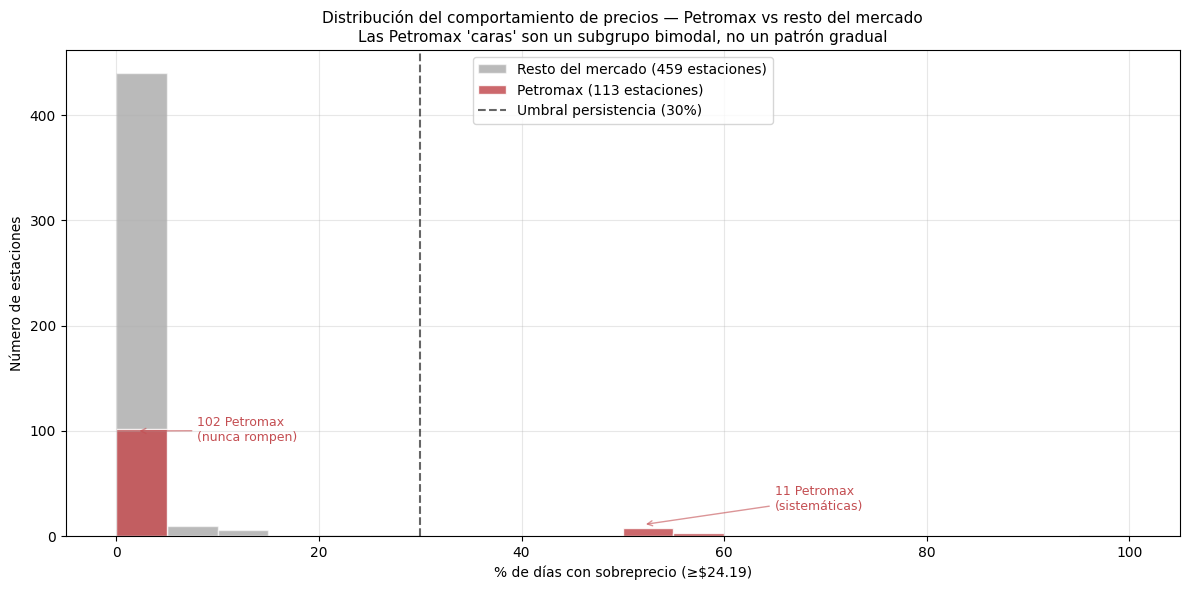


Patrón bimodal Petromax confirmado:
  Petromax con 0 días caros:        102
  Petromax con 1-29% días caros:    0
  Petromax con 30%+ días caros:     11


In [4]:
# Reconstruir la distribución de % de días caros para todas las Petromax
# (re-derivación a partir de magna, no depende de variables del notebook EDA)
magna_petromax = magna.merge(
    estaciones[estaciones["razon_social"].str.upper().str.contains("PETROMAX", na=False)][["num_per"]],
    left_on="numero_permiso", right_on="num_per"
)

# Cobertura por estación Petromax
cobertura_petromax = (
    magna_petromax.groupby("numero_permiso")["fecha"]
    .nunique()
    .reset_index()
    .rename(columns={"fecha": "dias_reportados"})
)
cobertura_petromax = cobertura_petromax[cobertura_petromax["dias_reportados"] >= 41]

# Días caros por estación Petromax
dias_caros_petromax = (
    magna_petromax[magna_petromax["precio"] >= UMBRAL_PRECIO_CARO]
    .groupby("numero_permiso")["fecha"]
    .nunique()
    .reset_index()
    .rename(columns={"fecha": "dias_arriba_umbral"})
)

# Combinar: todas las Petromax (las que nunca subieron precio aparecen con 0)
dist_petromax = cobertura_petromax.merge(dias_caros_petromax, on="numero_permiso", how="left")
dist_petromax["dias_arriba_umbral"] = dist_petromax["dias_arriba_umbral"].fillna(0)
dist_petromax["pct_dias_caros"] = (
    dist_petromax["dias_arriba_umbral"] / dist_petromax["dias_reportados"] * 100
)

# Mismo para no-Petromax
magna_otras = magna[~magna["numero_permiso"].isin(magna_petromax["numero_permiso"])]
cobertura_otras = (
    magna_otras.groupby("numero_permiso")["fecha"]
    .nunique()
    .reset_index()
    .rename(columns={"fecha": "dias_reportados"})
)
cobertura_otras = cobertura_otras[cobertura_otras["dias_reportados"] >= 41]

dias_caros_otras = (
    magna_otras[magna_otras["precio"] >= UMBRAL_PRECIO_CARO]
    .groupby("numero_permiso")["fecha"]
    .nunique()
    .reset_index()
    .rename(columns={"fecha": "dias_arriba_umbral"})
)
dist_otras = cobertura_otras.merge(dias_caros_otras, on="numero_permiso", how="left")
dist_otras["dias_arriba_umbral"] = dist_otras["dias_arriba_umbral"].fillna(0)
dist_otras["pct_dias_caros"] = (
    dist_otras["dias_arriba_umbral"] / dist_otras["dias_reportados"] * 100
)

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))

bins = np.arange(0, 105, 5)

ax.hist(dist_otras["pct_dias_caros"], bins=bins, color="#8C8C8C",
        alpha=0.6, label=f"Resto del mercado ({len(dist_otras)} estaciones)",
        edgecolor="white")
ax.hist(dist_petromax["pct_dias_caros"], bins=bins, color="#C44E52",
        alpha=0.85, label=f"Petromax ({len(dist_petromax)} estaciones)",
        edgecolor="white")

ax.axvline(30, color="black", linestyle="--", alpha=0.6,
           label="Umbral persistencia (30%)")

ax.set_xlabel("% de días con sobreprecio (≥$24.19)")
ax.set_ylabel("Número de estaciones")
ax.set_title("Distribución del comportamiento de precios — Petromax vs resto del mercado\n"
             "Las Petromax 'caras' son un subgrupo bimodal, no un patrón gradual",
             fontsize=11)
ax.legend(loc="upper center")
ax.grid(True, alpha=0.3)

# Anotaciones del patrón bimodal
ax.annotate(
    f"{(dist_petromax['pct_dias_caros'] == 0).sum()} Petromax\n(nunca rompen)",
    xy=(2, 100), xytext=(8, 90),
    fontsize=9, ha="left", color="#C44E52",
    arrowprops=dict(arrowstyle="->", color="#C44E52", alpha=0.6),
)
ax.annotate(
    f"11 Petromax\n(sistemáticas)",
    xy=(52, 11), xytext=(65, 25),
    fontsize=9, ha="left", color="#C44E52",
    arrowprops=dict(arrowstyle="->", color="#C44E52", alpha=0.6),
)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "processed" / "fig02_bimodal_petromax.png", bbox_inches="tight")
plt.show()

print(f"\nPatrón bimodal Petromax confirmado:")
print(f"  Petromax con 0 días caros:        {(dist_petromax['pct_dias_caros'] == 0).sum()}")
print(f"  Petromax con 1-29% días caros:    {((dist_petromax['pct_dias_caros'] > 0) & (dist_petromax['pct_dias_caros'] < 30)).sum()}")
print(f"  Petromax con 30%+ días caros:     {(dist_petromax['pct_dias_caros'] >= 30).sum()}")

## Hallazgo 4 — Concentración geográfica en el corredor oriente

Las 11 estaciones Petromax que rompen el precio no están distribuidas aleatoriamente por la ZM Monterrey. Están **concentradas en el corredor oriente**: Apodaca, Guadalupe, Juárez, San Nicolás y Cadereyta. La diferencia respecto a las 109 Petromax que cobran al precio coordinado es nítida:

- **Petromax sistemáticas (11)**: longitud media -100.13°, rango -100.20° a -99.99°.
- **Petromax al precio de mercado (109)**: longitud media -100.30°, distribuidas por toda la mancha urbana.
- **Diferencia: 17 km de desplazamiento medio hacia el oriente**.

Es relevante notar que **ninguna de las 11 está en San Pedro Garza García** ni en zonas tradicionalmente premium del poniente (Carretera Nacional, Cumbres). El sobreprecio sistemático no responde al patrón intuitivo de "zonas caras = precios caros".

Sin datos adicionales (volumen vehicular, perfil socioeconómico de la zona, presencia de competencia directa) no es posible validar la causa del patrón. Las hipótesis razonables incluyen: (1) clientela industrial cautiva en corredores de manufactura del oriente, (2) menor saturación de marcas premium competidoras en esa zona, (3) costo de búsqueda elevado para consumidores de Cadereyta y municipios alejados. Esto se reporta como observación, no como conclusión.

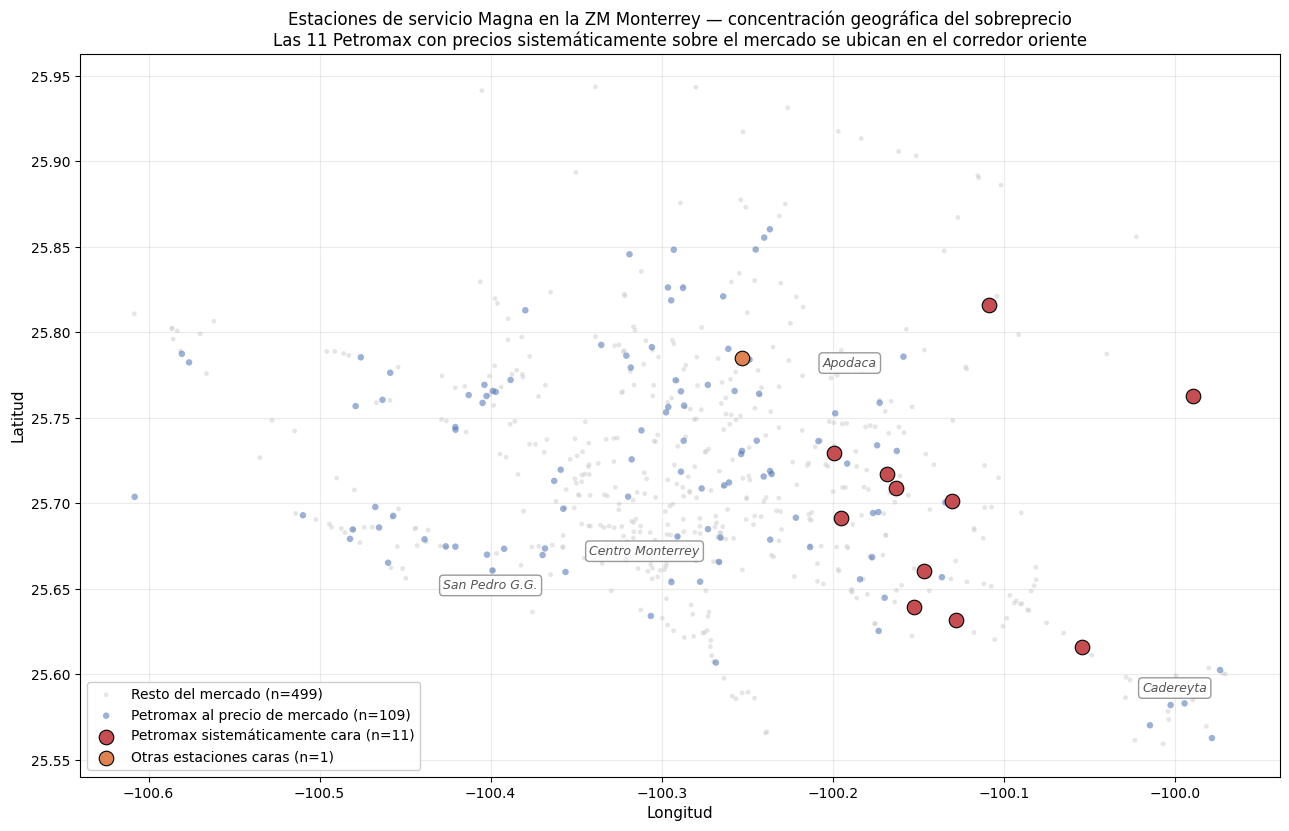

In [5]:
# Mapa final del análisis: distribución geográfica del sobreprecio
fig, ax = plt.subplots(figsize=(13, 10))

# Reconstruir categorías
estaciones_viz = estaciones.copy()
estaciones_viz["es_petromax"] = (
    estaciones_viz["razon_social"].str.upper().str.contains("PETROMAX", na=False)
)

permisos_caras_petromax = set(
    candidatas[candidatas["marca_inferida"] == "PETROMAX"]["numero_permiso"]
)
permisos_caras_otras = set(
    candidatas[candidatas["marca_inferida"] != "PETROMAX"]["numero_permiso"]
)

def categorizar(row):
    if row["num_per"] in permisos_caras_petromax:
        return "Petromax sistemáticamente cara"
    if row["num_per"] in permisos_caras_otras:
        return "Otras estaciones caras"
    if row["es_petromax"]:
        return "Petromax al precio de mercado"
    return "Resto del mercado"

estaciones_viz["categoria"] = estaciones_viz.apply(categorizar, axis=1)

# Configuración visual: paleta consistente con figuras anteriores
config = {
    "Resto del mercado":              ("#CCCCCC", 0.5, 12, 1),
    "Petromax al precio de mercado":  ("#4C72B0", 0.55, 22, 2),
    "Petromax sistemáticamente cara": ("#C44E52", 1.0, 110, 4),
    "Otras estaciones caras":         ("#DD8452", 1.0, 110, 4),
}

for cat, (color, alpha, size, zorder) in config.items():
    subset = estaciones_viz[estaciones_viz["categoria"] == cat]
    ax.scatter(
        subset["lng"], subset["lat"],
        c=color, alpha=alpha, s=size,
        edgecolors="black" if "cara" in cat else "none",
        linewidths=0.8,
        label=f"{cat} (n={len(subset)})",
        zorder=zorder,
    )

# Anotaciones de zonas urbanas de referencia
zonas_referencia = {
    "Centro Monterrey":     (-100.31, 25.67),
    "San Pedro G.G.":       (-100.40, 25.65),
    "Apodaca":              (-100.19, 25.78),
    "Cadereyta":            (-100.00, 25.59),
}

for nombre, (lng, lat) in zonas_referencia.items():
    ax.annotate(
        nombre,
        xy=(lng, lat),
        fontsize=9,
        color="#555555",
        style="italic",
        ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#888888", alpha=0.85),
        zorder=5,
    )

ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
ax.set_title(
    "Estaciones de servicio Magna en la ZM Monterrey — concentración geográfica del sobreprecio\n"
    "Las 11 Petromax con precios sistemáticamente sobre el mercado se ubican en el corredor oriente",
    fontsize=12,
)
ax.legend(loc="lower left", fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "processed" / "fig03_mapa_geografico.png", bbox_inches="tight")
plt.show()


## Hallazgo 5 — Impacto monetario al consumidor desinformado

El costo anual del sobreprecio depende del **patrón de visita** del consumidor. Para un consumo estándar de 50 L semanales (un tanque promedio) durante 52 semanas:

| Estación | Sobreprecio típico | % días caros | Costo aleatorio | Costo siempre |
|---|---|---|---|---|
| Segas Combustibles (San Nicolás) | \$1.00/L | 100% | **\$2,600/año** | **\$2,600/año** |
| Petromax PL/13580 (Apodaca) | \$0.40/L | 55% | \$689/año | \$1,248/año |
| Petromax típica del subgrupo | $0.30/L | 50% | 390–650 pesos/año | 780–1,300 pesos/año |

**Dos columnas con interpretaciones distintas:**

- **Costo aleatorio:** el consumidor visita la estación al azar a lo largo del año, así que paga sobreprecio solo en el porcentaje de días que la estación lo cobra. Es el escenario más realista para un consumidor genérico que pasa cerca varias veces al mes.
- **Costo siempre:** el consumidor visita la estación únicamente cuando casualmente está cobrando caro. Es el peor caso (poco probable, pero teórico).

El rango realista de pérdida anual para un consumidor que llena en una de las 11 Petromax sistemáticas está entre **390 y 689 pesos al año**.. Para el caso aislado de Segas Combustibles, **\$2,600/año** sin importar el día.

A nivel agregado, considerando que las 12 estaciones tienen consumos diarios típicos del orden de cientos a miles de litros, el sobreprecio anual extraído del bolsillo del consumidor en el agregado de las 12 estaciones identificadas se estima en el orden de **decenas de millones de pesos**, aunque su cuantificación precisa requeriría datos de volumen de venta no disponibles en el dataset público.

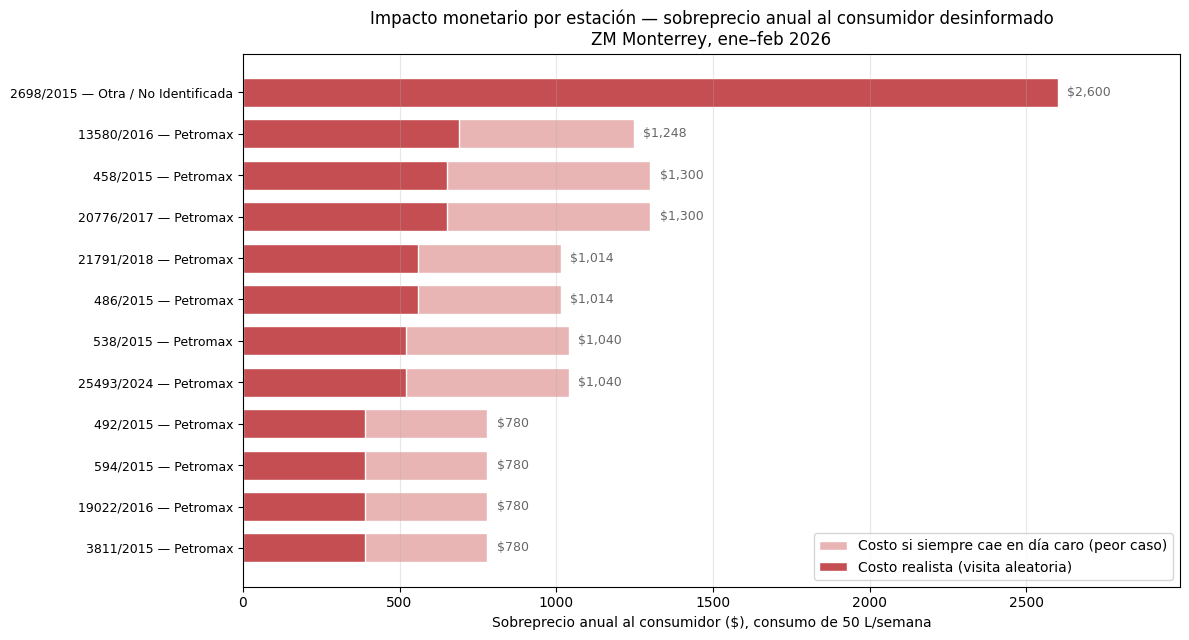


Resumen del impacto:
  Estaciones identificadas:  12
  Costo aleatorio promedio:  $692/año
  Costo aleatorio máximo:    $2600/año (Segas)
  Costo aleatorio mediano:   $540/año


In [6]:
# Visualización resumen del impacto monetario
fig, ax = plt.subplots(figsize=(12, 6.5))

# Ordenar por costo aleatorio (escenario realista)
plot_data = tabla_caras.sort_values("costo_anual_aleatorio", ascending=True).reset_index(drop=True)
plot_data["etiqueta"] = (
    plot_data["numero_permiso"].str.replace("PL/", "").str.replace("/EXP/ES", "")
    + " — "
    + plot_data["marca_inferida"].str.title()
)

y_pos = np.arange(len(plot_data))

# Barras horizontales: costo siempre (claro) detrás, costo aleatorio (oscuro) encima
ax.barh(y_pos, plot_data["costo_anual_siempre"],
        color="#E8B4B4", edgecolor="white", height=0.7,
        label="Costo si siempre cae en día caro (peor caso)")
ax.barh(y_pos, plot_data["costo_anual_aleatorio"],
        color="#C44E52", edgecolor="white", height=0.7,
        label="Costo realista (visita aleatoria)")

# Etiquetas numéricas al final de cada barra
for i, row in plot_data.iterrows():
    ax.text(row["costo_anual_siempre"] + 30, i,
            f"${row['costo_anual_siempre']:,}",
            va="center", ha="left", fontsize=9, color="#666666")

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data["etiqueta"], fontsize=9)
ax.set_xlabel("Sobreprecio anual al consumidor ($), consumo de 50 L/semana", fontsize=10)
ax.set_title(
    "Impacto monetario por estación — sobreprecio anual al consumidor desinformado\n"
    "ZM Monterrey, ene–feb 2026",
    fontsize=12,
)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3, axis="x")
ax.set_xlim(0, plot_data["costo_anual_siempre"].max() * 1.15)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "processed" / "fig04_impacto_monetario.png", bbox_inches="tight")
plt.show()

# Resumen final
print(f"\nResumen del impacto:")
print(f"  Estaciones identificadas:  {len(plot_data)}")
print(f"  Costo aleatorio promedio:  ${plot_data['costo_anual_aleatorio'].mean():.0f}/año")
print(f"  Costo aleatorio máximo:    ${plot_data['costo_anual_aleatorio'].max():.0f}/año (Segas)")
print(f"  Costo aleatorio mediano:   ${plot_data['costo_anual_aleatorio'].median():.0f}/año")

## Conclusiones

Este análisis identifica un patrón concreto y accionable en el mercado de gasolina Magna en la Zona Metropolitana de Monterrey:

1. **El mercado opera bajo un precio coordinado** de $23.99/L que abarca ~73% de las observaciones estación-día durante los 58 días observados.
2. Apenas **2.1% de las estaciones rompen el precio** de manera sistemática (12 de 572 con cobertura suficiente).
3. **11 de 12 son operaciones específicas de Petromax**, pero representan solo **9.7% de las 113 Petromax con cobertura suficiente**. El comportamiento es de subgrupo, no de marca completa.
4. El subgrupo se concentra en el **corredor oriente de la ZM** (Apodaca–Guadalupe–Juárez–Cadereyta), no en zonas premium tradicionales.
5. El sobreprecio anual realista para un consumidor que llena 50 L semanales en una de estas estaciones está entre **$390 y $1,040**, escalando a **$2,600** en el caso aislado de Segas Combustibles.

El hallazgo es defendible para un cliente de tipo "app de comparación de precios" o "medio de periodismo de datos": no se trata de denunciar a una marca completa, sino de identificar 12 ubicaciones específicas en un mapa donde el consumidor desinformado paga arriba del mercado.

## Limitaciones del análisis

Estas limitaciones se reportan explícitamente, no se ocultan:

- **Ventana temporal de 58 días.** Suficiente para detectar persistencia (≥30% de días observados implica ≥17 días con sobreprecio), pero no suficiente para validar estacionalidad o respuestas a eventos de mercado puntuales (cambios fiscales, fluctuaciones del peso). Una ampliación a 6–12 meses fortalecería las conclusiones de persistencia.
- **Diciembre 2025 no disponible** en archivos públicos al cierre del análisis. La ventana resulta de 2 meses contiguos en lugar de 3.
- **La marca de cada estación se infiere de la razón social** mediante búsqueda heurística (regex sobre patrones explícitos como "PETROMAX"). Las estaciones con razón social que no contiene la marca quedan etiquetadas como "no identificada". No se contó con un catálogo oficial de abanderamientos para validación cruzada. Esto subestima el conteo de algunas marcas distintas a Pemex/Petromax con razón social genérica.
- **El análisis usa precios promedio diarios** publicados por la CNE, no los seis cortes intra-día originales del sistema CRE. Variaciones intra-día (subidas/bajadas durante el mismo día) no son visibles.
- **El filtrado a la ZM Monterrey usa bounding box geográfico**, no spatial join contra el shapefile oficial del Marco Geoestadístico Nacional de INEGI. El bbox captura ~1% de estaciones de bordes de Coahuila/Tamaulipas que técnicamente están fuera de la ZM. Ninguna está en el subgrupo de las 11 caras, por lo que no afecta el hallazgo principal.
- **No se cuenta con datos de volumen de venta por estación**, por lo que la cuantificación de impacto monetario agregado al consumidor no es posible con precisión. Los cálculos individuales son robustos para una canasta de consumo estándar (50 L/semana).
- **Las hipótesis sobre la causa del patrón geográfico** (clientela industrial, menor competencia local, costo de búsqueda) no son validables con este dataset y se reportan como observaciones, no como conclusiones.

## Trabajo futuro

- Ampliar la ventana temporal a 12 meses y validar la persistencia del subgrupo Petromax.
- Cruzar con datos de parque vehicular y volumen de tráfico por municipio para validar las hipótesis del corredor oriente.
- Integrar el catálogo oficial de marcas/abanderamientos de la CNE cuando esté disponible para refinar la segmentación por marca.
- Replicar el análisis en otras zonas metropolitanas de México (CDMX, Guadalajara) para identificar si el patrón "subgrupo geográfico de marca dominante" se repite.

---

*Análisis realizado con datos abiertos de la Comisión Nacional de Energía (CNE) y el padrón histórico de la Comisión Reguladora de Energía (CRE). Datos públicos disponibles en datos.gob.mx.*

In [7]:
# Exports para Looker Studio
EXPORTS = PROJECT_ROOT / "data" / "processed" / "looker_exports"
EXPORTS.mkdir(parents=True, exist_ok=True)

# ===========================================================
# CSV 1 — Las 620 estaciones de la ZM Monterrey con categoría
# ===========================================================
estaciones_export = estaciones.copy()
estaciones_export["es_petromax"] = (
    estaciones_export["razon_social"].str.upper().str.contains("PETROMAX", na=False)
)

permisos_caras_petromax = set(
    candidatas[candidatas["marca_inferida"] == "PETROMAX"]["numero_permiso"]
)
permisos_caras_otras = set(
    candidatas[candidatas["marca_inferida"] != "PETROMAX"]["numero_permiso"]
)

def categorizar_export(row):
    if row["num_per"] in permisos_caras_petromax:
        return "Petromax cara"
    if row["num_per"] in permisos_caras_otras:
        return "Otra cara"
    if row["es_petromax"]:
        return "Petromax precio mercado"
    return "Resto mercado"

estaciones_export["categoria"] = estaciones_export.apply(categorizar_export, axis=1)

# Mediana de precio por estación (para tooltip del mapa)
mediana_por_estacion = (
    magna.groupby("numero_permiso")["precio"]
    .median()
    .reset_index()
    .rename(columns={"numero_permiso": "num_per", "precio": "precio_mediano"})
)
estaciones_export = estaciones_export.merge(mediana_por_estacion, on="num_per", how="left")

# Looker Studio espera "lat,lng" en una sola columna para mapas
estaciones_export["coordenadas"] = (
    estaciones_export["lat"].astype(str) + "," + estaciones_export["lng"].astype(str)
)

# Renombrar columnas a algo limpio para Looker (sin tildes, snake_case)
estaciones_final = estaciones_export.rename(columns={
    "num_per": "permiso",
    "razon_social": "razon_social",
}).copy()

# Selección final de columnas
cols_estaciones = [
    "permiso", "razon_social", "categoria",
    "lat", "lng", "coordenadas", "precio_mediano",
]
estaciones_final = estaciones_final[cols_estaciones]

estaciones_final.to_csv(EXPORTS / "looker_estaciones_zm.csv", index=False)
print(f"CSV 1: {len(estaciones_final)} estaciones → looker_estaciones_zm.csv")
print(estaciones_final.head(3).to_string())
print()

# ===========================================================
# CSV 2 — Las 12 estaciones del análisis con métricas
# ===========================================================
candidatas_export = candidatas.copy()
candidatas_export["sobreprecio_dias_caros"] = (
    candidatas_export["precio_promedio_dias_caros"] - PRECIO_REFERENCIA
).round(2)

candidatas_export["costo_anual_aleatorio"] = (
    candidatas_export["sobreprecio_dias_caros"]
    * (candidatas_export["pct_dias_caros"] / 100)
    * 50 * 52
).round(0).astype(int)

candidatas_export["costo_anual_siempre"] = (
    candidatas_export["sobreprecio_dias_caros"] * 50 * 52
).round(0).astype(int)

candidatas_export["coordenadas"] = (
    candidatas_export["lat"].astype(str) + "," + candidatas_export["lng"].astype(str)
)

candidatas_final = candidatas_export.rename(columns={
    "numero_permiso": "permiso",
    "marca_inferida": "marca",
    "precio_mediano_total": "precio_mediano",
    "precio_promedio_dias_caros": "precio_promedio_caro",
    "pct_dias_caros": "pct_dias_caros",
}).copy()

cols_candidatas = [
    "permiso", "razon_social", "marca",
    "lat", "lng", "coordenadas",
    "precio_mediano", "precio_promedio_caro", "sobreprecio_dias_caros",
    "dias_arriba_umbral", "dias_reportados", "pct_dias_caros",
    "costo_anual_aleatorio", "costo_anual_siempre",
]
candidatas_final = candidatas_final[cols_candidatas]
candidatas_final = candidatas_final.sort_values("pct_dias_caros", ascending=False).reset_index(drop=True)

candidatas_final.to_csv(EXPORTS / "looker_estaciones_caras.csv", index=False)
print(f"CSV 2: {len(candidatas_final)} estaciones → looker_estaciones_caras.csv")
print(candidatas_final[["permiso", "razon_social", "marca", "pct_dias_caros", "costo_anual_aleatorio"]].head(5).to_string(index=False))
print()

# ===========================================================
# CSV 3 — Serie temporal de precios diarios por categoría
# (para gráfica de evolución en el dashboard)
# ===========================================================
magna_con_categoria = magna.merge(
    estaciones_final[["permiso", "categoria"]],
    left_on="numero_permiso", right_on="permiso", how="inner"
)

evolucion = (
    magna_con_categoria.groupby(["fecha", "categoria"])["precio"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={"mean": "precio_promedio", "median": "precio_mediano", "count": "estaciones"})
)
evolucion["fecha"] = evolucion["fecha"].dt.strftime("%Y-%m-%d")

evolucion.to_csv(EXPORTS / "looker_evolucion_diaria.csv", index=False)
print(f"CSV 3: {len(evolucion)} filas (fecha × categoria) → looker_evolucion_diaria.csv")
print(evolucion.head(8).to_string(index=False))
print()

# Verificación final
print("Archivos generados:")
for f in sorted(EXPORTS.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

CSV 1: 620 estaciones → looker_estaciones_zm.csv
              permiso            razon_social                categoria       lat       lng         coordenadas  precio_mediano
0  PL/425/EXP/ES/2015  Petromax, S.A. de C.V.  Petromax precio mercado  25.71970 -100.3590    25.7197,-100.359           23.99
1  PL/426/EXP/ES/2015  Petromax, S.A. de C.V.  Petromax precio mercado  25.60693 -100.2683  25.60693,-100.2683           23.99
2  PL/427/EXP/ES/2015  Petromax, S.A. de C.V.  Petromax precio mercado  25.67366 -100.3682  25.67366,-100.3682           23.99

CSV 2: 12 estaciones → looker_estaciones_caras.csv
             permiso                razon_social                  marca  pct_dias_caros  costo_anual_aleatorio
 PL/2698/EXP/ES/2015 Segas Combustibles Sa de Cv OTRA / NO IDENTIFICADA      100.000000                   2600
PL/13580/EXP/ES/2016      Petromax, S.A. de C.V.               PETROMAX       55.172414                    689
  PL/486/EXP/ES/2015      Petromax, S.A. de C.V.          

In [8]:
%who DataFrame

candidatas	 candidatas_export	 candidatas_final	 cobertura_otras	 cobertura_petromax	 dias_caros_otras	 dias_caros_petromax	 dist_otras	 dist_petromax	 
estaciones	 estaciones_export	 estaciones_final	 estaciones_viz	 evolucion	 magna	 magna_con_categoria	 magna_otras	 magna_petromax	 
mediana_por_estacion	 plot_data	 subset	 tabla_caras	 tabla_display	 zoom_data	 


In [9]:
# === EXPORT: Tabla de las 12 estaciones a PNG para README ===
import dataframe_image as dfi
from pathlib import Path

# Path de salida
out_path = PROJECT_ROOT / "data" / "processed" / "tabla_12_estaciones.png"

# Exportar el Styler directo
dfi.export(
    styled,
    str(out_path),
    table_conversion="matplotlib",  # backend sin Chrome
    dpi=200,
)

print(f"Tabla exportada: {out_path}")
print(f"Tamaño: {out_path.stat().st_size / 1024:.1f} KB")

Tabla exportada: /home/osiel/proyectos/gasolineras-mty/data/processed/tabla_12_estaciones.png
Tamaño: 491.3 KB
